<a href="https://www.kaggle.com/code/stanislavgridin/eda-ai-agent-rag?scriptVersionId=241758141" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Описание проекта. 
Разработка AI-агента для ответов на вопросы по курсам облачного провайдера. Для каких сценариев применяется AI-агент:

ответ на вопрос - в каком модуле курса можно найти интересующую информацию;
ответить на вопрос по содержанию курса;
суммаризировать текст.
Ссылка на Github:https://github.com/gridstan89/MFDP 

AI-агент будет реализован на базе RAG:
- использование embedding-модели;
- хранение всей базы курсов в Json в S3-хранилище;
- применение векторной БД Milvus;
- полнотекстовый поиск: OpenSearch;
- фреймворк Langchain;
- reranker-модель;
- LLM по API для генерации ответов. 

Собрал датасет: https://disk.yandex.ru/d/hpuNn5NrrFD8lA

В рамках задания по EDA планирую:
1) провести анализ специфических аспектов, важных для эффективного извлечения и использования информации: 
- аналих структуры данных и распределения данных (исследование типов документов и их количество, выявление форматов и структур данных, оценка размеров документов в токенах);
- лингвистический анализ (оценка длины контента,терминологии и специфических словарей, лемматизация, стемминг);
2) определить baseline (планирую начать с tf-df не с BERT, как рекомендует Техножрица, далее перейти к моделям BERT),оценивать планирую отдельные компоненты при помощи RAGAS;
3) провести оценку качества генерации LLM без контекста и с контекстом. 
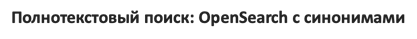
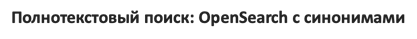
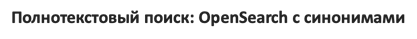
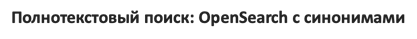

Основной формат документов курса - тектовые лонгриды, поиск планирую осуществлять по этим текстам. Средний размер текста ~ 3400 токенов. 
Загрузил датасет в виде архива из отдельных json-файлов для дальнейшего удобства использования в RAG с векторными БД.

In [1]:
# Импорт необходимых библиотек
import os
import pandas as pd
import re
import nltk
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from collections import Counter

# Скачиваем необходимые ресурсы NLTK
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Загрузка и первичная обработка данных

In [2]:
# Поиск всех файлов с контентом курса
course_files = []

for root, dirs, files in os.walk("/kaggle/input/"):
    for file in files:
        if file.endswith('.json'):
            file_path = os.path.join(root, file)
            course_files.append(file_path)

print(f"Найдено {len(course_files)} файлов с контентом курса")

# Создаем структуру для хранения данных
course_data = []

for file_path in tqdm(course_files, desc="Загрузка файлов"):
    try:
        # Читаем файл как обычный текст
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # Извлекаем метаданные из пути к файлу
        path_parts = file_path.split('/')
        filename = path_parts[-1]
        module_name = filename.replace('.json', '')
        
        # Определяем курс из структуры директорий
        course_name = path_parts[-2] if len(path_parts) > 2 else "Неизвестный курс"
        
        # Определяем категорию/тему курса (если возможно)
        category = path_parts[-3] if len(path_parts) > 3 else "Общая категория"
        
        # Создаем запись для DataFrame
        course_entry = {
            'module_name': module_name,
            'course_name': course_name,
            'category': category,
            'content': content,
            'file_path': file_path,
            'content_length': len(content)
        }
        
        course_data.append(course_entry)
        
    except Exception as e:
        print(f"Ошибка при обработке файла {file_path}: {e}")

# Создаем DataFrame
if course_data:
    df = pd.DataFrame(course_data)
    print(f"\nУспешно создан DataFrame с {len(df)} записями")
    print("\nСтруктура данных:")
    print(df.info())
    print("\nПримеры данных:")
    print(df[['module_name', 'course_name', 'content_length']].head())
else:
    print("Не удалось загрузить данные в DataFrame")
    # Останавливаем выполнение, если данные не загружены
    import sys
    sys.exit()

Найдено 56 файлов с контентом курса


Загрузка файлов:   0%|          | 0/56 [00:00<?, ?it/s]


Успешно создан DataFrame с 56 записями

Структура данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   module_name     56 non-null     object
 1   course_name     56 non-null     object
 2   category        56 non-null     object
 3   content         56 non-null     object
 4   file_path       56 non-null     object
 5   content_length  56 non-null     int64 
dtypes: int64(1), object(5)
memory usage: 2.8+ KB
None

Примеры данных:
                    module_name                  course_name  content_length
0          Модуль 4. Подготовка  Cloud.ru Cloud Fundamentals           11269
1                   Итоги курса  Cloud.ru Cloud Fundamentals             933
2    Модуль 7. Хранилища данных  Cloud.ru Cloud Fundamentals           29759
3  Модуль 3. Законы и стандарты  Cloud.ru Cloud Fundamentals            9792
4          Модуль 5. Управлени

EDA/Разведочный анализ данных


--- РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ ---

Статистика по длине контента (в символах):
Минимальная длина: 303
Средняя длина: 14750.09
Медианная длина: 11928.00
Максимальная длина: 37373


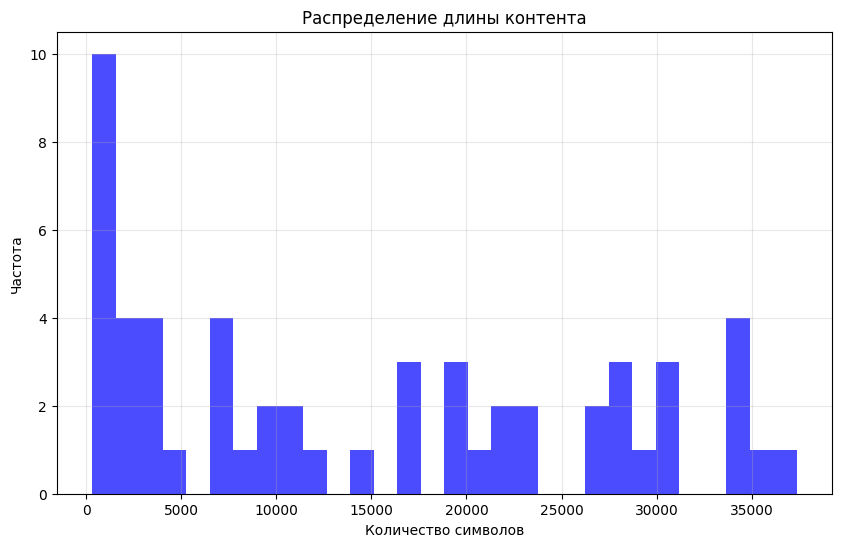


Распределение документов по курсам:
course_name
Cloud.ru Cloud Fundamentals          10
Короткие описания курсов              9
Cloud.ru Advanced                     9
Cloud.ru Evolution Fundamentlas       7
Базовый курс Облако VMware            7
Быстрый старт в Cloud.ru ML Space     6
Cloud.ru Evolution                    4
Вводный курс Cloud.ru Advanced        3
Облачные сервисы для бизнеса          1
Name: count, dtype: int64


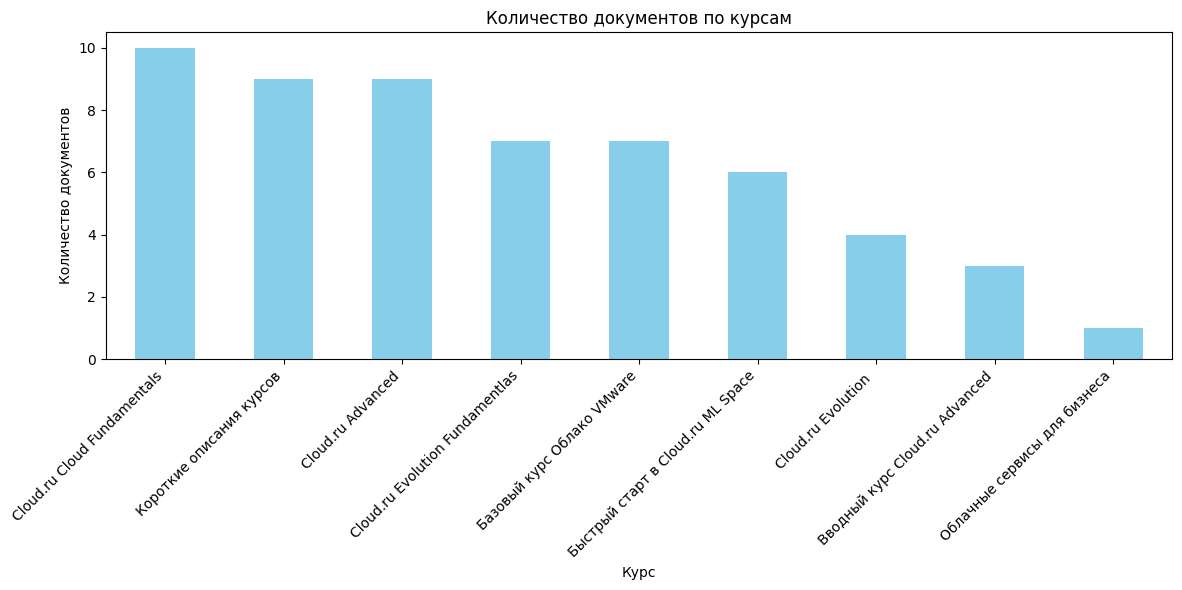

In [3]:
print("\n--- РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ ---")

# Статистика по длине контента
print(f"\nСтатистика по длине контента (в символах):")
print(f"Минимальная длина: {df['content_length'].min()}")
print(f"Средняя длина: {df['content_length'].mean():.2f}")
print(f"Медианная длина: {df['content_length'].median():.2f}")
print(f"Максимальная длина: {df['content_length'].max()}")

# Визуализация распределения длины контента
plt.figure(figsize=(10, 6))
plt.hist(df['content_length'], bins=30, alpha=0.7, color='blue')
plt.title('Распределение длины контента')
plt.xlabel('Количество символов')
plt.ylabel('Частота')
plt.grid(alpha=0.3)
plt.savefig('content_length_distribution.png')
plt.show()

# Распределение по курсам
course_counts = df['course_name'].value_counts()
print(f"\nРаспределение документов по курсам:")
print(course_counts)

# Визуализация распределения по курсам
plt.figure(figsize=(12, 6))
course_counts.plot(kind='bar', color='skyblue')
plt.title('Количество документов по курсам')
plt.xlabel('Курс')
plt.ylabel('Количество документов')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('course_distribution.png')
plt.show()

Очистка и подготовка текста

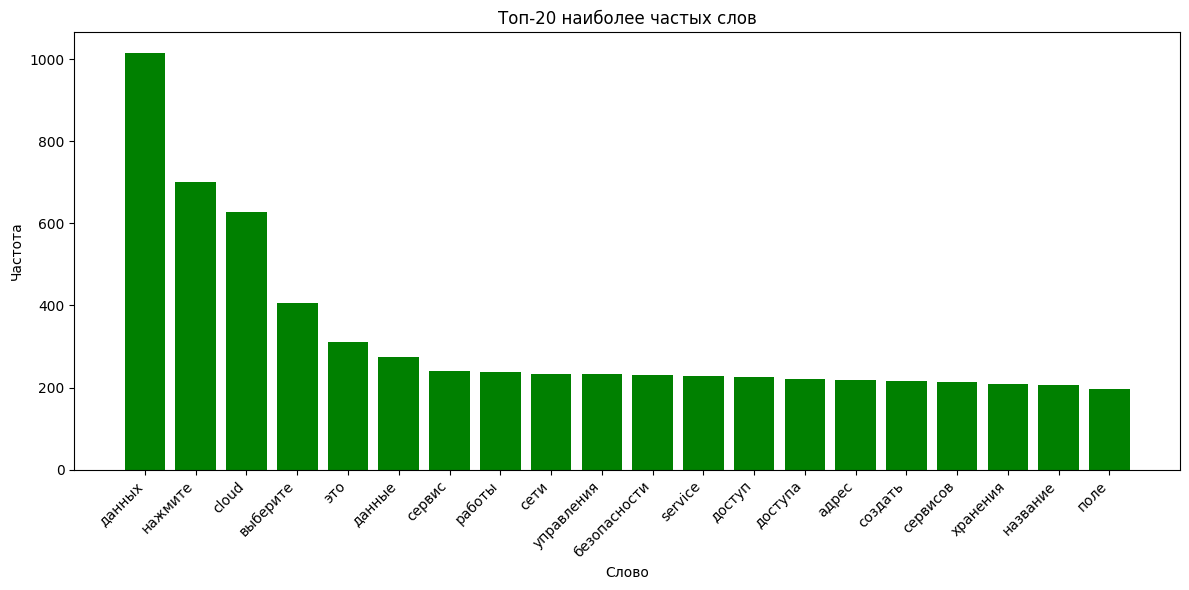

In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text)
    
    # Удаление специальных символов (опционально)
    # text = re.sub(r'[^\w\s]', ' ', text)
    
    return text.strip()

# Применяем очистку
df['clean_content'] = df['content'].apply(clean_text)

# Создаем объединенный текст для анализа частотности слов
all_text = " ".join(df['clean_content'])

# Получаем список русских стоп-слов
try:
    russian_stopwords = set(stopwords.words('russian'))
except:
    russian_stopwords = set()
    print("Не удалось загрузить русские стоп-слова")

# Разделяем на слова и подсчитываем частоту
words = re.findall(r'\b\w+\b', all_text.lower())
word_freq = Counter(words)

# Удаляем стоп-слова
filtered_word_freq = {word: count for word, count in word_freq.items() 
                     if word not in russian_stopwords and len(word) > 2}

# Визуализируем топ-20 слов
top_words = dict(sorted(filtered_word_freq.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(12, 6))
plt.bar(top_words.keys(), top_words.values(), color='green')
plt.title('Топ-20 наиболее частых слов')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_words.png')
plt.show()

Разбиение на фрагменты для RAG

In [5]:
def split_text_into_chunks(text, max_chunk_size=1000, overlap=100):
    """
    Разбивает текст на фрагменты подходящего для RAG размера.
    Использует параграфы как естественные границы для разбиения.
    """
    # Разбиение по абзацам
    paragraphs = re.split(r'\n\s*\n', text)
    paragraphs = [p.strip() for p in paragraphs if p.strip()]
    
    chunks = []
    current_chunk = ""
    
    for para in paragraphs:
        # Если параграф сам по себе больше максимального размера, нужно его разбить
        if len(para) > max_chunk_size:
            # Если в текущем куске уже что-то есть, добавляем его в список
            if current_chunk:
                chunks.append(current_chunk)
                current_chunk = ""
            
            # Разбиваем длинный параграф на куски
            sentences = nltk.sent_tokenize(para)
            current_sentence_chunk = ""
            
            for sentence in sentences:
                if len(current_sentence_chunk) + len(sentence) <= max_chunk_size:
                    current_sentence_chunk += sentence + " "
                else:
                    if current_sentence_chunk:
                        chunks.append(current_sentence_chunk.strip())
                    current_sentence_chunk = sentence + " "
            
            if current_sentence_chunk:
                chunks.append(current_sentence_chunk.strip())
        
        # Если добавление текущего параграфа не превысит максимальный размер
        elif len(current_chunk) + len(para) <= max_chunk_size:
            current_chunk += para + "\n\n"
        else:
            # Если превысит, добавляем текущий кусок в список и начинаем новый
            chunks.append(current_chunk.strip())
            current_chunk = para + "\n\n"
    
    # Добавляем оставшийся кусок
    if current_chunk:
        chunks.append(current_chunk.strip())
    
    # Добавляем перекрытие между фрагментами
    if overlap > 0 and len(chunks) > 1:
        chunks_with_overlap = [chunks[0]]
        for i in range(1, len(chunks)):
            # Добавляем начало текущего фрагмента к концу предыдущего
            prev_chunk = chunks[i-1]
            curr_chunk = chunks[i]
            
            # Если предыдущий фрагмент достаточно короткий, не добавляем перекрытие
            if len(prev_chunk) < max_chunk_size - overlap:
                chunks_with_overlap.append(curr_chunk)
                continue
            
            # Определяем текст для перекрытия
            if len(curr_chunk) <= overlap:
                overlap_text = curr_chunk
            else:
                overlap_text = curr_chunk[:overlap]
            
            # Объединяем с перекрытием
            if not prev_chunk.endswith(overlap_text):
                chunks_with_overlap[-1] = chunks_with_overlap[-1] + "\n\n" + overlap_text
            chunks_with_overlap.append(curr_chunk)
        
        chunks = chunks_with_overlap
    
    return chunks

# Создаем фрагменты для каждого документа
all_chunks = []

# Определение оптимального размера фрагмента
# Для использования в RAG обычно рекомендуются размеры 512-1024 токенов
# Примерно 3-5 символов на токен для русского языка
chunk_size = 3000  # примерно 600-1000 токенов
overlap_size = 200  # небольшое перекрытие для сохранения контекста

print(f"\nРазбиваем документы на фрагменты (размер: {chunk_size}, перекрытие: {overlap_size})...")

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Создание фрагментов"):
    document_chunks = split_text_into_chunks(row['clean_content'], 
                                            max_chunk_size=chunk_size, 
                                            overlap=overlap_size)
    
    for i, chunk in enumerate(document_chunks):
        chunk_data = {
            'chunk_id': f"{row['module_name']}_chunk_{i+1}",
            'module_name': row['module_name'],
            'course_name': row['course_name'],
            'category': row['category'],
            'chunk_text': chunk,
            'chunk_index': i,
            'total_chunks': len(document_chunks),
            'original_file': row['file_path'],
            'chunk_length': len(chunk)
        }
        all_chunks.append(chunk_data)

# Создаем DataFrame с фрагментами
chunks_df = pd.DataFrame(all_chunks)
print(f"\nСоздано {len(chunks_df)} фрагментов текста для RAG")

# Статистика по фрагментам
print(f"\nСтатистика по длине фрагментов (в символах):")
print(f"Минимальная длина: {chunks_df['chunk_length'].min()}")
print(f"Средняя длина: {chunks_df['chunk_length'].mean():.2f}")
print(f"Медианная длина: {chunks_df['chunk_length'].median():.2f}")
print(f"Максимальная длина: {chunks_df['chunk_length'].max()}")


Разбиваем документы на фрагменты (размер: 3000, перекрытие: 200)...


Создание фрагментов:   0%|          | 0/56 [00:00<?, ?it/s]


Создано 307 фрагментов текста для RAG

Статистика по длине фрагментов (в символах):
Минимальная длина: 214
Средняя длина: 2784.33
Медианная длина: 3125.00
Максимальная длина: 5015


Проверка качества фрагментов 

In [6]:
# Выведем несколько примеров фрагментов для проверки качества
if len(chunks_df) > 0:
    print("\n--- ПРИМЕРЫ ФРАГМЕНТОВ ---")
    sample_chunks = chunks_df.sample(min(3, len(chunks_df)))
    
    for idx, row in sample_chunks.iterrows():
        print(f"\nФрагмент: {row['chunk_id']} ({row['chunk_index']+1}/{row['total_chunks']})")
        print(f"Курс: {row['course_name']}")
        print(f"Размер: {row['chunk_length']} символов")
        print(f"Начало текста: {row['chunk_text'][:150]}...")


--- ПРИМЕРЫ ФРАГМЕНТОВ ---

Фрагмент: Федерация консоли облака Advanced с доме_chunk_5 (5/5)
Курс: Cloud.ru Advanced
Размер: 655 символов
Начало текста: Введите логин от доменной учетной записи в формате «domain\username» или «username@domain», пароль и нажмите Вход. Откроется страница консоли Advanced...

Фрагмент: Лабораторные Container Apps и Artifact Registry_chunk_7 (7/7)
Курс: Cloud.ru Evolution 
Размер: 1204 символов
Начало текста: ../_images/ca-config1.png Дождитесь, когда контейнер и ревизия перейдут в статус «Выполняется». ../_images/ca-run.png 7. Добавьте вебхук в Telegram Чт...

Фрагмент: Модуль 2. Сервисы PaaS_chunk_4 (4/12)
Курс: Вводный курс Cloud.ru Advanced
Размер: 3085 символов
Начало текста: Это платформа с открытым исходным кодом для развертывания, масштабирования, управления и контроля контейнеризованных приложений либо сервисов. CCE Clo...


Создание метаданных для RAG

In [7]:
# Добавляем метаданные, которые будут полезны при извлечении и ранжировании
chunks_df['metadata'] = chunks_df.apply(
    lambda row: {
        'module_name': row['module_name'],
        'course_name': row['course_name'],
        'category': row['category'],
        'chunk_index': int(row['chunk_index']),
        'total_chunks': int(row['total_chunks']),
        'source_file': row['original_file'],
    },
    axis=1
)

Сохранение результатов 

In [8]:
# Создаем директорию для сохранения результатов
output_dir = "/kaggle/working/rag_data"
os.makedirs(output_dir, exist_ok=True)

# Сохраняем оригинальные документы
df.to_csv(f'{output_dir}/course_documents.csv', index=False)

# Сохраняем фрагменты для RAG
chunks_df.to_csv(f'{output_dir}/course_chunks_for_rag.csv', index=False)

Baseline проекта.

In [9]:
pip install ragas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.3/438.3 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfull

In [10]:
pip install langchain

Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install langchain ragas

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install -q sentence-transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [13]:
# Импорт необходимых библиотек
import os
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch
from sentence_transformers import SentenceTransformer
import json
from typing import List, Dict, Any, Tuple
import nltk
nltk.download('punkt')

# Импортируем RAGAS для оценки
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)

from ragas import evaluate
import random 

2025-05-25 11:53:16.540469: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748173996.723269      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748173996.771210      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Загрузка подготовленных данных

In [14]:
# Путь к фрагментам данных
chunks_path = "/kaggle/working/rag_data/course_chunks_for_rag.csv"
chunks_df = pd.read_csv(chunks_path)

print(f"Загружено {len(chunks_df)} фрагментов текста")
print(chunks_df[['chunk_id', 'module_name', 'chunk_length']].head())

# Создадим словарь метаданных
chunks_df['metadata_json'] = chunks_df.apply(
    lambda row: json.dumps({
        'module_name': row['module_name'],
        'course_name': row['course_name'],
        'chunk_index': int(row['chunk_index']),
        'total_chunks': int(row['total_chunks']),
        'source_file': row['original_file'],
    }, ensure_ascii=False),
    axis=1
)

Загружено 307 фрагментов текста
                       chunk_id           module_name  chunk_length
0  Модуль 4. Подготовка_chunk_1  Модуль 4. Подготовка          3037
1  Модуль 4. Подготовка_chunk_2  Модуль 4. Подготовка          3143
2  Модуль 4. Подготовка_chunk_3  Модуль 4. Подготовка          3148
3  Модуль 4. Подготовка_chunk_4  Модуль 4. Подготовка          2393
4           Итоги курса_chunk_1           Итоги курса           922


Реализация TF-DF baseline

In [15]:
class TFIDFRetriever:
    def __init__(self, documents, text_column='chunk_text'):
        self.documents = documents
        self.text_column = text_column
        self.vectorizer = TfidfVectorizer(max_features=10000)
        
        corpus = documents[text_column].tolist()
        self.tfidf_matrix = self.vectorizer.fit_transform(corpus)
        print(f"Создана TF-IDF матрица размером: {self.tfidf_matrix.shape}")
    
    def retrieve(self, query, top_k=5):
        # Преобразуем запрос в TF-IDF вектор
        query_vector = self.vectorizer.transform([query])
        
        # Вычисляем косинусное сходство между запросом и всеми документами
        similarities = cosine_similarity(query_vector, self.tfidf_matrix).flatten()
        
        # Находим индексы документов с наивысшей схожестью
        top_indices = similarities.argsort()[-top_k:][::-1]
        
        # Формируем результаты
        results = []
        for idx in top_indices:
            doc = self.documents.iloc[idx]
            results.append({
                'content': doc[self.text_column],
                'metadata': json.loads(doc['metadata_json']),
                'score': float(similarities[idx]),
                'id': doc['chunk_id']
            })
        
        return results

Реализация embedding-модели (multilingual-e5-large)

In [16]:
class EmbeddingRetriever:
    def __init__(self, documents, text_column='chunk_text'):
        self.documents = documents
        self.text_column = text_column

         # Определяем device для sentence-transformers
        import torch
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        
        # Загружаем модель multilingual-e5-large
        try:
            print("Загружаем модель multilingual-e5-large...")
            self.model = SentenceTransformer('intfloat/multilingual-e5-large', device=device)
            print("Модель успешно загружена")
        except Exception as e:
            print(f"Ошибка при загрузке модели: {e}")
            print("Используем запасную модель...")
            self.model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)
        
        # Векторизуем все документы
        print("Векторизуем документы...")
        corpus = documents[text_column].tolist()
        self.embeddings = self.model.encode(corpus, show_progress_bar=True)
        print(f"Созданы эмбеддинги размером: {self.embeddings.shape}")
    
    def retrieve(self, query, top_k=5):
        # Кодируем запрос
        query_embedding = self.model.encode([query])[0]
        
        # Вычисляем косинусное сходство
        similarities = cosine_similarity([query_embedding], self.embeddings)[0]
        
        # Находим индексы документов с наивысшей схожестью
        top_indices = similarities.argsort()[-top_k:][::-1]
        
        # Формируем результаты
        results = []
        for idx in top_indices:
            doc = self.documents.iloc[idx]
            results.append({
                'content': doc[self.text_column],
                'metadata': json.loads(doc['metadata_json']),
                'score': float(similarities[idx]),
                'id': doc['chunk_id']
            })
        
        return results

Реализация reranker-модели (bert-multilingual-passage-reranking-msmarco)

In [17]:
class RerankerRetriever:
    def __init__(self, base_retriever, reranker_model_name="amberoad/bert-multilingual-passage-reranking-msmarco"):
        self.base_retriever = base_retriever
        
        # Для reranker загрузим преобразователь предложений с функцией переранжирования
        try:
            print(f"Загружаем модель {reranker_model_name}...")
            self.reranker = SentenceTransformer(reranker_model_name, device=device)
            print("Модель переранжирования успешно загружена")
            self.use_reranker = True
        except Exception as e:
            print(f"Ошибка при загрузке модели переранжирования: {e}")
            print("Переранжирование будет пропущено")
            self.use_reranker = False
    
    def retrieve(self, query, top_k=5, initial_k=10):
        # Получаем начальные результаты (больше, чем нужно)
        initial_results = self.base_retriever.retrieve(query, top_k=initial_k)
        
        if not self.use_reranker or len(initial_results) <= top_k:
            return initial_results[:top_k]
        
        # Переранжируем результаты
        passages = [r['content'] for r in initial_results]
        passage_embeddings = self.reranker.encode(passages)
        query_embedding = self.reranker.encode([query])[0]
        # Вычисляем сходство
        similarities = cosine_similarity([query_embedding], passage_embeddings)[0]
        
        # Сортируем результаты по новым оценкам
        ranked_indices = similarities.argsort()[::-1]
        reranked_results = []
        
        for idx in ranked_indices[:top_k]:
            result = initial_results[idx]
            result['score'] = float(similarities[idx])  # Обновляем оценку
            reranked_results.append(result)
        
        return reranked_results

Создание генератора ответов

In [18]:
class SimpleRAGSystem:
    def __init__(self, retriever, query_prefix="", max_tokens=1000):
        self.retriever = retriever
        self.query_prefix = query_prefix
        self.max_tokens = max_tokens
    
    def answer(self, question, top_k=5):
        # Получаем релевантные фрагменты
        retrieved_docs = self.retriever.retrieve(question, top_k=top_k)
        
        # Базовый prompt для соединения контекста и вопроса
        context = "\n\n".join([doc['content'] for doc in retrieved_docs])
        
        # Создаем простой ответ на основе контекста (поскольку мы не используем LLM)
        # Для RAG baseline будем просто возвращать лучший фрагмент как ответ
        if len(retrieved_docs) > 0:
            best_doc = retrieved_docs[0]['content']
            # Создадим короткий ответ, выбрав первое предложение
            sentences = nltk.sent_tokenize(best_doc)
            answer = " ".join(sentences[:3]) if sentences else "Информация не найдена."
        else:
            answer = "Информация не найдена."
        
        return {
            'question': question,
            'answer': answer,
            'contexts': [doc['content'] for doc in retrieved_docs],
            'sources': [doc['metadata'] for doc in retrieved_docs]
        }

Генерация тестовых запросов 

In [19]:
def generate_test_questions(chunks_df, n_questions=20):
    """
    Генерирует тестовые вопросы на основе фрагментов данных.
    Для каждого вопроса выбирает случайный фрагмент и формулирует вопрос.
    """
    test_questions = []
    
    # Получаем уникальные модули
    modules = chunks_df['module_name'].unique()
    
    # Определяем шаблоны вопросов
    question_templates = [
        "Что такое {topic}?",
        "Какие основные принципы {topic}?",
        "Объясните концепцию {topic}.",
        "Как работает {topic}?",
        "В чем преимущества {topic}?",
        "Опишите процесс {topic}.",
        "Каковы ключевые особенности {topic}?",
        "Какие есть виды {topic}?",
        "Когда применяется {topic}?",
        "Какие проблемы решает {topic}?"
    ]
    
    # Выбираем случайные модули и создаем вопросы
    selected_modules = random.sample(list(modules), min(n_questions, len(modules)))
    
    for module in selected_modules:
        # Выбираем случайный фрагмент из этого модуля
        module_chunks = chunks_df[chunks_df['module_name'] == module]
        chunk = module_chunks.sample(1).iloc[0]
        
        # Извлекаем потенциальную тему вопроса из названия модуля
        topic = module.split('.')[-1].strip() if '.' in module else module
        
        # Выбираем случайный шаблон вопроса
        template = random.choice(question_templates)
        question = template.format(topic=topic)
        
        # Сохраняем тестовый вопрос и его "золотой" контекст
        test_questions.append({
            'question': question,
            'reference_context': chunk['chunk_text'],
            'module': module,
            'chunk_id': chunk['chunk_id']
        })
    
    return pd.DataFrame(test_questions)

Настройка и выполнение оценки с помощью Ragas-метрик. Для оценки контекста здесь оставляю только faithfulness.

In [20]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import re
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Загружаем необходимые ресурсы NLTK
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

def prepare_evaluation_dataset(questions_df, rag_system):
    """
    Подготавливает данные для оценки RAG системы.
    """
    evaluation_data = []
    
    for _, row in tqdm(questions_df.iterrows(), total=len(questions_df), desc="Генерация ответов"):
        question = row['question']
        
        # Получаем ответ от RAG системы
        result = rag_system.answer(question, top_k=3)
        
        # Добавляем к данным для оценки
        evaluation_data.append({
            'question': question,
            'answer': result['answer'],
            'contexts': result['contexts'],
            'reference_context': row['reference_context']  # Используем исходный контекст как эталонный ответ
        })
    
    return pd.DataFrame(evaluation_data)

# Кастомные метрики оценки

def preprocess_text(text):
    """Предобработка текста: приведение к нижнему регистру, удаление стоп-слов и пунктуации"""
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    stop_words = set(stopwords.words('russian') + stopwords.words('english'))
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    return " ".join(tokens)

def calculate_faithfulness(answer, contexts):
    """
    Оценивает достоверность (faithfulness) ответа - насколько ответ 
    основан на предоставленных контекстах и не содержит галлюцинаций.
    
    Метод: проверяет, насколько токены из ответа присутствуют в контекстах.
    """
    if not answer or not contexts:
        return 0.0
    
    # Предобработка
    answer_processed = preprocess_text(answer)
    all_contexts = " ".join(contexts)
    contexts_processed = preprocess_text(all_contexts)
    
    # Разбиваем на токены
    answer_tokens = set(answer_processed.split())
    context_tokens = set(contexts_processed.split())
    
    if not answer_tokens:
        return 0.0
    
    # Находим, сколько токенов из ответа присутствует в контекстах
    tokens_in_context = answer_tokens.intersection(context_tokens)
    
    # Считаем достоверность как отношение токенов из ответа, которые есть в контексте
    return len(tokens_in_context) / len(answer_tokens)

def evaluate_rag_system(test_data):
    """
    Оценивает качество RAG системы с помощью кастомных метрик.
    """
    results = {
        'faithfulness': []
    }
    
    for _, row in tqdm(test_data.iterrows(), total=len(test_data), desc="Оценка RAG"):
        # Рассчитываем все метрики
        faith = calculate_faithfulness(row['answer'], row['contexts'])
        
        # Добавляем результаты
        results['faithfulness'].append(faith)
    
    # Рассчитываем средние значения для каждой метрики
    avg_results = {
        'faithfulness': np.mean(results['faithfulness'])
    }
    
    # Добавляем детализированные результаты для каждого примера
    avg_results['detailed'] = pd.DataFrame(results)
    
    return avg_results

def print_evaluation_summary(evaluation_results):
    """
    Печатает сводку результатов оценки RAG системы.
    """
    print("\n===== ОЦЕНКА КАЧЕСТВА КОНТЕКСТА =====")
    print(f"Faithfulness: {evaluation_results['faithfulness']:.3f} - Насколько ответ основан на предоставленных контекстах")
    
    # Вычисляем общий балл как среднее по всем метрикам
    avg_score = np.mean([
        evaluation_results['faithfulness']
    ])
    
    print(f"\nОбщий балл: {avg_score:.3f}")
    print("=====================================")

def visualize_metrics(evaluation_results):
    """
    Визуализирует результаты оценки метрик.
    """
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        # Настраиваем стиль
        sns.set(style="whitegrid")
        
        # Создаем данные для визуализации
        metrics = ['Faithfulness']
        values = [
            evaluation_results['faithfulness']
        ]
        
        # Создаем столбчатую диаграмму
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x=metrics, y=values, palette="viridis")
        
        # Добавляем значения над столбцами
        for i, value in enumerate(values):
            ax.text(i, value + 0.01, f'{value:.3f}', ha='center', fontsize=12)
        
        # Настраиваем оси и заголовок
        plt.ylim(0, 1.1)
        plt.ylabel('Значение метрики')
        plt.title('Метрики оценки RAG системы', fontsize=16, pad=20)
        
        # Отображаем диаграмму
        plt.tight_layout()
        plt.show()
        
        # Визуализация распределения значений метрик для всех примеров
        detailed_df = evaluation_results['detailed']
        
        plt.figure(figsize=(12, 8))
        sns.boxplot(data=detailed_df, palette="Set3")
        plt.title('Распределение значений метрик', fontsize=16, pad=20)
        plt.ylabel('Значение')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()
        
    except ImportError:
        print("Для визуализации установите matplotlib и seaborn: pip install matplotlib seaborn")
    except Exception as e:
        print(f"Ошибка при визуализации: {e}")

# Пример использования:
def run_evaluation(questions_df, rag_system):
    """
    Запускает полный процесс оценки RAG системы.
    """
    print("1. Подготовка данных для оценки...")
    evaluation_data = prepare_evaluation_dataset(questions_df, rag_system)
    
    print("\n2. Оценка контекста...")
    evaluation_results = evaluate_rag_system(evaluation_data)
    
    print("\n3. Вывод результатов оценки:")
    print_evaluation_summary(evaluation_results)
    
    print("\n4. Визуализация результатов:")
    visualize_metrics(evaluation_results)
    
    return evaluation_results, evaluation_data

Выполнение теста

In [21]:
# Генерируем тестовые вопросы
print("\nГенерация тестовых вопросов...")
test_questions = generate_test_questions(chunks_df, n_questions=15)
print(f"Создано {len(test_questions)} тестовых вопросов")
print("\nПримеры вопросов:")
for i, (_, row) in enumerate(test_questions.head(3).iterrows()):
    print(f"{i+1}. {row['question']} (Модуль: {row['module']})")

# Инициализируем ретриверы
print("\nИнициализация TF-IDF Retriever (baseline)...")
tfidf_retriever = TFIDFRetriever(chunks_df)

print("\nИнициализация Embedding Retriever...")
embedding_retriever = EmbeddingRetriever(chunks_df)

print("\nИнициализация Reranker Retriever...")
reranker_retriever = RerankerRetriever(embedding_retriever)

# Инициализируем RAG системы
print("\nСоздание RAG систем...")
baseline_rag = SimpleRAGSystem(tfidf_retriever)
embedding_rag = SimpleRAGSystem(embedding_retriever)
reranker_rag = SimpleRAGSystem(reranker_retriever)

# ОЦЕНКА BASELINE (TF-IDF)
print("\n--- ОЦЕНКА TF-IDF BASELINE ---")
baseline_data = prepare_evaluation_dataset(test_questions, baseline_rag)
baseline_results = evaluate_rag_system(baseline_data)

# ОЦЕНКА EMBEDDING-BASED RAG
print("\n--- ОЦЕНКА EMBEDDING-BASED RAG ---")
embedding_data = prepare_evaluation_dataset(test_questions, embedding_rag)
embedding_results = evaluate_rag_system(embedding_data)

# ОЦЕНКА RERANKER-BASED RAG
print("\n--- ОЦЕНКА RERANKER-BASED RAG ---")
reranker_data = prepare_evaluation_dataset(test_questions, reranker_rag)
reranker_results = evaluate_rag_system(reranker_data)


Генерация тестовых вопросов...
Создано 15 тестовых вопросов

Примеры вопросов:
1. В чем преимущества Хранилища данных? (Модуль: Модуль 7. Хранилища данных)
2. Когда применяется Завершение? (Модуль: Завершение)
3. Что такое Бэкенд как сервис с Supabase и облаком A? (Модуль: Бэкенд как сервис с Supabase и облаком A)

Инициализация TF-IDF Retriever (baseline)...
Создана TF-IDF матрица размером: (307, 10000)

Инициализация Embedding Retriever...
Загружаем модель multilingual-e5-large...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

Генерация ответов:  80%|████████  | 12/15 [00:00<00:00, 30.17it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Оценка RAG: 100%|██████████| 15/15 [00:00<00:00, 113.68it/s]


Визуализация и анализ результатов 

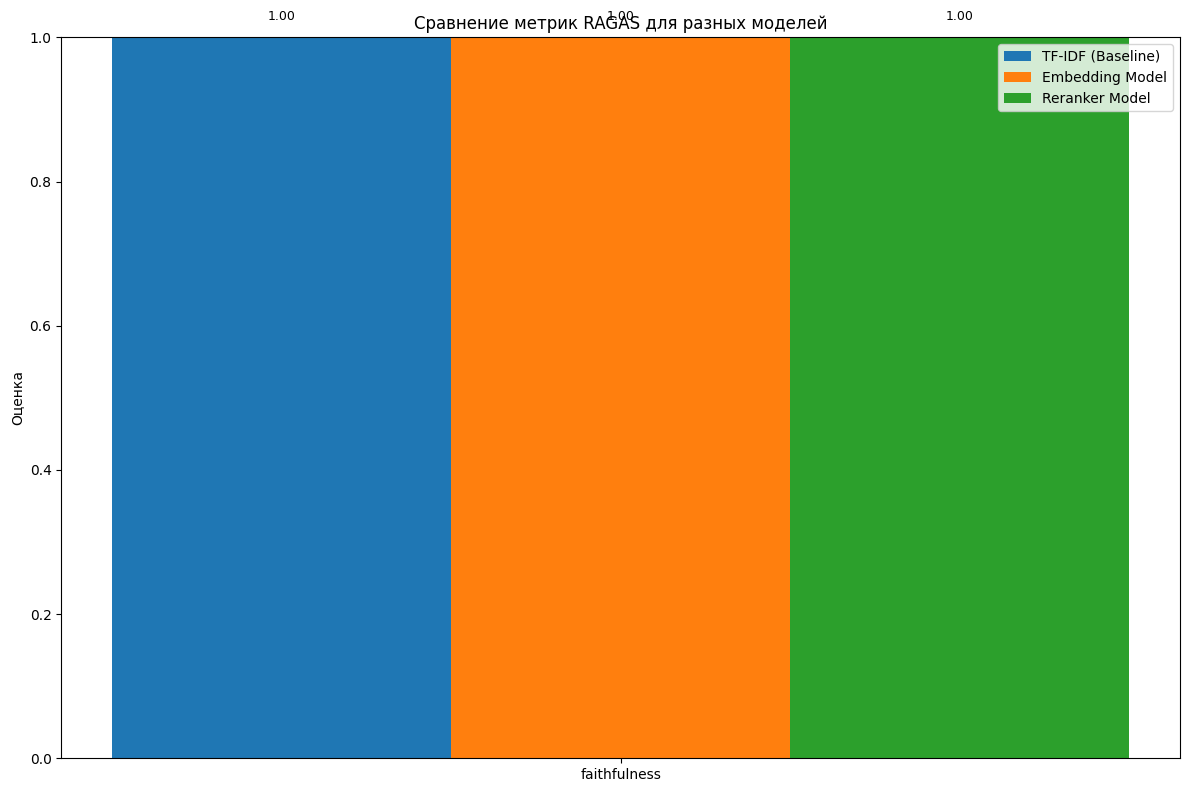


--- СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ---
                Метрика  TF-IDF (Baseline)  Embedding Model  Reranker Model
Точность (faithfulness)                1.0              1.0             1.0


In [22]:
def visualize_ragas_comparison(results_dict):
    """
    Визуализирует сравнение метрик RAGAS для разных моделей.
    """
    metrics = ['faithfulness']
    models = list(results_dict.keys())
    
    # Подготовка данных для визуализации
    data = {metric: [results_dict[model][metric] for model in models] for metric in metrics}
    
    # Строим бар-плот
    fig, ax = plt.figure(figsize=(12, 8)), plt.subplot(111)
    width = 0.2
    x = np.arange(len(metrics))
    
    # Строим столбцы для каждой модели
    for i, model in enumerate(models):
        ax.bar(x + i*width - width*(len(models)-1)/2, 
               [results_dict[model][metric] for metric in metrics], 
               width, label=model)
    
    # Добавляем подписи и легенду
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel('Оценка')
    ax.set_title('Сравнение метрик RAGAS для разных моделей')
    ax.legend()
    ax.set_ylim(0, 1)
    
    # Добавляем текстовые значения над столбцами
    for i, model in enumerate(models):
        for j, metric in enumerate(metrics):
            score = results_dict[model][metric]
            ax.text(j + i*width - width*(len(models)-1)/2, score + 0.02, 
                   f'{score:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('ragas_comparison.png')
    plt.show()

# Собираем результаты
all_results = {
    'TF-IDF (Baseline)': {m: baseline_results[m] for m in baseline_results},
    'Embedding Model': {m: embedding_results[m] for m in embedding_results},
    'Reranker Model': {m: reranker_results[m] for m in reranker_results}
}

# Визуализируем сравнение
visualize_ragas_comparison(all_results)

# Выводим сводную таблицу
print("\n--- СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ---")
results_df = pd.DataFrame({
    'Метрика': ['Точность (faithfulness)'],
    'TF-IDF (Baseline)': [
        baseline_results['faithfulness']
    ],
    'Embedding Model': [
        embedding_results['faithfulness']
    ],
    'Reranker Model': [
        reranker_results['faithfulness']
    ]
})

print(results_df.to_string(index=False))

Анализ примеров

In [23]:
def show_example_responses(test_questions, baseline_data, embedding_data, reranker_data, num_examples=3):
    """
    Показывает примеры ответов от разных моделей для одинаковых вопросов.
    """
    print("\n--- ПРИМЕРЫ ОТВЕТОВ ---")
    
    for i in range(min(num_examples, len(test_questions))):
        question = test_questions.iloc[i]['question']
        print(f"\nВопрос {i+1}: {question}")
        
        # Вывод ответов от разных моделей
        print("\nTF-IDF (Baseline):")
        print(f"Ответ: {baseline_data.iloc[i]['answer']}")
        print(f"Первый контекст: {baseline_data.iloc[i]['contexts'][0][:150]}...")
        
        print("\nEmbedding Model:")
        print(f"Ответ: {embedding_data.iloc[i]['answer']}")
        print(f"Первый контекст: {embedding_data.iloc[i]['contexts'][0][:150]}...")
        
        print("\nReranker Model:")
        print(f"Ответ: {reranker_data.iloc[i]['answer']}")
        print(f"Первый контекст: {reranker_data.iloc[i]['contexts'][0][:150]}...")
        
        print("\nЭталонный контекст:")
        print(f"{test_questions.iloc[i]['reference_context'][:150]}...")
        
        print("-" * 80)

# Показываем примеры ответов
show_example_responses(test_questions, baseline_data, embedding_data, reranker_data)



--- ПРИМЕРЫ ОТВЕТОВ ---

Вопрос 1: В чем преимущества Хранилища данных?

TF-IDF (Baseline):
Ответ: 2️⃣ Резервное копирование и восстановление Одна из ключевых функций — возможность создания резервных копий данных для защиты от потери информации из-за сбоев оборудования, ошибок пользователя или кибератак. Системы также предоставляют инструменты для быстрого восстановления данных после сбоев. 3️⃣ Репликация и синхронизация данных Для обеспечения высокой доступности и отказоустойчивости данных системы хранения могут реплицировать данные между различными физическими местоположениями и синхронизировать их для обеспечения консистентности.
Первый контекст: 2️⃣ Резервное копирование и восстановление Одна из ключевых функций — возможность создания резервных копий данных для защиты от потери информации из-з...

Embedding Model:
Ответ: ☑️ Контроль и безопасность Организации имеют полный контроль над своими системами хранения данных, что позволяет внедрять строгие меры безопасности и соответствов

Сохранение результатов 


Инициализация Reranker Retriever...
Загружаем модель amberoad/bert-multilingual-passage-reranking-msmarco...
Ошибка при загрузке модели переранжирования: name 'device' is not defined
Переранжирование будет пропущено

Создание RAG систем...

--- ОЦЕНКА TF-IDF BASELINE ---


Оценка RAG: 100%|██████████| 15/15 [00:00<00:00, 110.38it/s]



===== ОЦЕНКА КАЧЕСТВА КОНТЕКСТА =====
Faithfulness: 1.000 - Насколько ответ основан на предоставленных контекстах

Общий балл: 1.000

--- ОЦЕНКА EMBEDDING-BASED RAG ---


Генерация ответов:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Оценка RAG: 100%|██████████| 15/15 [00:00<00:00, 117.10it/s]


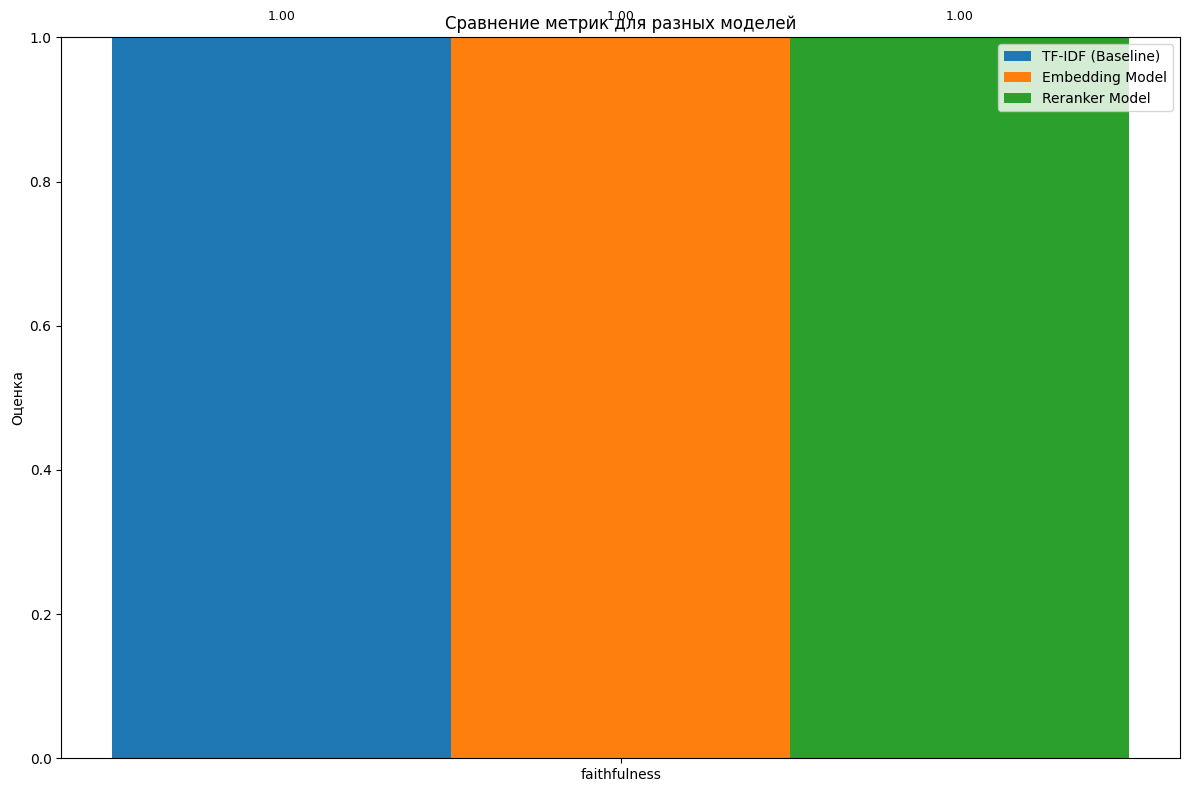


--- СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ---
                Метрика  TF-IDF (Baseline)  Embedding Model  Reranker Model
Точность (faithfulness)                1.0              1.0             1.0

--- ПРИМЕРЫ ОТВЕТОВ ---

Вопрос 1: В чем преимущества Хранилища данных?

TF-IDF (Baseline):
Ответ: 2️⃣ Резервное копирование и восстановление Одна из ключевых функций — возможность создания резервных копий данных для защиты от потери информации из-за сбоев оборудования, ошибок пользователя или кибератак. Системы также предоставляют инструменты для быстрого восстановления данных после сбоев. 3️⃣ Репликация и синхронизация данных Для обеспечения высокой доступности и отказоустойчивости данных системы хранения могут реплицировать данные между различными физическими местоположениями и синхронизировать их для обеспечения консистентности.
Первый контекст: 2️⃣ Резервное копирование и восстановление Одна из ключевых функций — возможность создания резервных копий данных для защиты от потери информации из-з..

In [24]:
print("\nИнициализация Reranker Retriever...")
reranker_retriever = RerankerRetriever(embedding_retriever)

# Инициализируем RAG системы
print("\nСоздание RAG систем...")
baseline_rag = SimpleRAGSystem(tfidf_retriever)
embedding_rag = SimpleRAGSystem(embedding_retriever)
reranker_rag = SimpleRAGSystem(reranker_retriever)

# ОЦЕНКА BASELINE (TF-IDF)
print("\n--- ОЦЕНКА TF-IDF BASELINE ---")
baseline_data = prepare_evaluation_dataset(test_questions, baseline_rag)
baseline_results = evaluate_rag_system(baseline_data)
print_evaluation_summary(baseline_results)

# ОЦЕНКА EMBEDDING-BASED RAG
print("\n--- ОЦЕНКА EMBEDDING-BASED RAG ---")
embedding_data = prepare_evaluation_dataset(test_questions, embedding_rag)
embedding_results = evaluate_rag_system(embedding_data)

# ОЦЕНКА RERANKER-BASED RAG
print("\n--- ОЦЕНКА RERANKER-BASED RAG ---")
reranker_data = prepare_evaluation_dataset(test_questions, reranker_rag)
reranker_results = evaluate_rag_system(reranker_data)

# 9. ВИЗУАЛИЗАЦИЯ И АНАЛИЗ РЕЗУЛЬТАТОВ
#----------------------------------

def visualize_ragas_comparison(results_dict):
    """
    Визуализирует сравнение метрик для разных моделей.
    """
    metrics = ['faithfulness']
    models = list(results_dict.keys())
    
    # Подготовка данных для визуализации
    data = {metric: [results_dict[model][metric] for model in models] for metric in metrics}
    
    # Строим бар-плот
    fig, ax = plt.figure(figsize=(12, 8)), plt.subplot(111)
    width = 0.2
    x = np.arange(len(metrics))
    
    # Строим столбцы для каждой модели
    for i, model in enumerate(models):
        ax.bar(x + i*width - width*(len(models)-1)/2, 
               [results_dict[model][metric] for metric in metrics], 
               width, label=model)
    
    # Добавляем подписи и легенду
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel('Оценка')
    ax.set_title('Сравнение метрик для разных моделей')
    ax.legend()
    ax.set_ylim(0, 1)
    
    # Добавляем текстовые значения над столбцами
    for i, model in enumerate(models):
        for j, metric in enumerate(metrics):
            score = results_dict[model][metric]
            ax.text(j + i*width - width*(len(models)-1)/2, score + 0.02, 
                   f'{score:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('ragas_comparison.png')
    plt.show()

# Собираем результаты
all_results = {
    'TF-IDF (Baseline)': {m: baseline_results[m] for m in baseline_results},
    'Embedding Model': {m: embedding_results[m] for m in embedding_results},
    'Reranker Model': {m: reranker_results[m] for m in reranker_results}
}

# Визуализируем сравнение
visualize_ragas_comparison(all_results)

# Выводим сводную таблицу
print("\n--- СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ---")
results_df = pd.DataFrame({
    'Метрика': ['Точность (faithfulness)'],
    'TF-IDF (Baseline)': [
        baseline_results['faithfulness']
    ],
    'Embedding Model': [
        embedding_results['faithfulness']
    ],
    'Reranker Model': [
        reranker_results['faithfulness']
    ]
})

print(results_df.to_string(index=False))

# 10. АНАЛИЗ ПРИМЕРОВ
#-----------------

def show_example_responses(test_questions, baseline_data, embedding_data, reranker_data, num_examples=3):
    """
    Показывает примеры ответов от разных моделей для одинаковых вопросов.
    """
    print("\n--- ПРИМЕРЫ ОТВЕТОВ ---")
    
    for i in range(min(num_examples, len(test_questions))):
        question = test_questions.iloc[i]['question']
        print(f"\nВопрос {i+1}: {question}")
        
        # Вывод ответов от разных моделей
        print("\nTF-IDF (Baseline):")
        print(f"Ответ: {baseline_data.iloc[i]['answer']}")
        print(f"Первый контекст: {baseline_data.iloc[i]['contexts'][0][:150]}...")
        
        print("\nEmbedding Model:")
        print(f"Ответ: {embedding_data.iloc[i]['answer']}")
        print(f"Первый контекст: {embedding_data.iloc[i]['contexts'][0][:150]}...")
        
        print("\nReranker Model:")
        print(f"Ответ: {reranker_data.iloc[i]['answer']}")
        print(f"Первый контекст: {reranker_data.iloc[i]['contexts'][0][:150]}...")
        
        print("\nЭталонный контекст:")
        print(f"{test_questions.iloc[i]['reference_context'][:150]}...")
        
        print("-" * 80)

# Показываем примеры ответов
show_example_responses(test_questions, baseline_data, embedding_data, reranker_data)

# 11. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
#------------------------

# Сохраняем тестовые вопросы
test_questions.to_csv('/kaggle/working/test_questions.csv', index=False)

# Сохраняем результаты оценки в CSV
results_df.to_csv('/kaggle/working/ragas_results.csv', index=False)

# Сохраняем примеры результатов
results_samples = pd.DataFrame({
    'question': baseline_data['question'],
    'baseline_answer': baseline_data['answer'],
    'embedding_answer': embedding_data['answer'],
    'reranker_answer': reranker_data['answer'],
    'reference_context': test_questions['reference_context']
})
results_samples.to_csv('/kaggle/working/answer_samples.csv', index=False)

print("\nРезультаты сохранены в рабочую директорию Kaggle.")
print("\n--- Тест завершен ---")

Подключаю LLM 
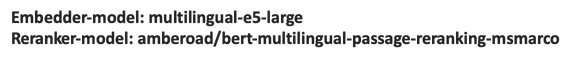
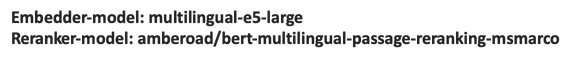
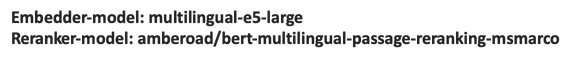
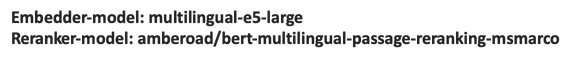

In [25]:
# подключаем Gigachat_API
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

client_id = user_secrets.get_secret("SBER_ID")
secret = user_secrets.get_secret("SBER_SECRET") 
auth = user_secrets.get_secret("SBER_AUTH")

In [26]:
import base64
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
client_id = user_secrets.get_secret("SBER_ID")
secret = user_secrets.get_secret("SBER_SECRET")

credentials = f"{client_id}:{secret}"
encoded_credentials = base64.b64encode(credentials.encode('utf-8')).decode('utf-8')

In [27]:
encoded_credentials == auth

True

In [28]:
import requests
import uuid

def get_token(auth_token, scope='GIGACHAT_API_PERS'):
    """
      Выполняет POST-запрос к эндпоинту, который выдает токен.

      Параметры:
      - auth_token (str): токен авторизации, необходимый для запроса.
      - область (str): область действия запроса API. По умолчанию — «GIGACHAT_API_PERS».

      Возвращает:
      - ответ API, где токен и срок его "годности".
      """
    # Создадим идентификатор UUID (36 знаков)
    rq_uid = str(uuid.uuid4())

    # API URL
    url = "https://ngw.devices.sberbank.ru:9443/api/v2/oauth"

    # Заголовки
    headers = {
        'Content-Type': 'application/x-www-form-urlencoded',
        'Accept': 'application/json',
        'RqUID': rq_uid,
        'Authorization': f'Basic {auth_token}'
    }

    # Тело запроса
    payload = {
        'scope': scope
    }

    try:
        # Делаем POST запрос с отключенной SSL верификацией
        # (можно скачать сертификаты Минцифры, тогда отключать проверку не надо)
        response = requests.post(url, headers=headers, data=payload, verify=False)
        return response
    except requests.RequestException as e:
        print(f"Ошибка: {str(e)}")
        return -1

In [29]:
response = get_token(auth)
if response != 1:
  print(response.text)
  giga_token = response.json()['access_token']

{"access_token":"eyJjdHkiOiJqd3QiLCJlbmMiOiJBMjU2Q0JDLUhTNTEyIiwiYWxnIjoiUlNBLU9BRVAtMjU2In0.k0qCg-5IH0F1xi36icwjDFKR5WrkTVgs1YOGQnGOyWNXjLO_Tg_YKyuAY651I-rXm9sth4jBCcE-PJxvxY9APhcKk-UAD3xv4y-e9nHplmJjS2TcCZn3tX3kOgoGnAn12Evd7m6eetEHFndXoHm4PqLcm4uVx0uuKL8_0lBhJHefwcny8IzgE5qF7LsLKNDFppmsWw8l6DuQPDfLwhQP6GWsEQUDTrBsEkKOPJrqeSfcbt3G1nIrFS4Dmzj_i7w_xthUqeNw_30o5L_cG7F9uBuZ4emFgsCRMQDjAeoKDQdK_EJW9Sp0Rx4onTeQ-KbwunCc9oc2Z4Noi4ExnGJctA.1TJ0Amoxs1_n0yft8iEEVw.hG0UkH58L98_syxyZaPLmZ-rmXNmYbZ0Y4wYfoo36bm7Lk1DJMZ602zN3ztBsIKXK4DW5gPWVYv3i_pJUmVfd9iTkcAEA1O7BhaI7BjNv6bP8b8zx1A0ZS8zm2Z_18fj77jbiEQmw3U_4cGIgc87FzApZMvWtmv11LrVieI0_No2jHSgPRh4Ni8u5f7dwS8R7YLS6HRk2xN4CCmYdKVmiu8NFznLnvtZKdOB6nnwMspvxl-IM__K5aP5EcYOcIsKXcOYo2L450hABryqQ185vGCD3996A9u6KZUZAgA0gZ6g79FOwbUrlkylJ3tMCK3sKoLi3CPKX00iUwch_E1KG5CJ28b8jwkqEXZFKxFRKo0Un8GfxrvAbkP190u4ilM6lMfAb3gCbkKPKCNbIKpunAnzQ3iBfXeIPl_0maGjlEZRxbceht4aSmyxm9eqWOyEv27UwNjPZQvxU9aHDWENj1AjvLH_-l9Cmjt0FHFHCom0AoLQNf9eOzr8HR2Ht9gW3Lk4P4lK9m1ojw0tMVAJ5JIKCapWi

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ngw.devices.sberbank.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [30]:
import requests

url = "https://gigachat.devices.sberbank.ru/api/v1/models"

payload={}
headers = {
  'Accept': 'application/json',
  'Authorization': f'Bearer {giga_token}'
}

response = requests.request("GET", url, headers=headers, data=payload, verify=False)

print(response.text)

{"object":"list","data":[{"id":"GigaChat","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-2","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-2-Max","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-2-Max-preview","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-2-Pro","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-2-Pro-preview","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-2-preview","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-Max","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-Max-preview","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-Plus","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-Plus-preview","object":"model","owned_by":"salutedevices","type":"chat"},{"id":"GigaChat-Pro","object":"model","owned_by":"sal

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.devices.sberbank.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Установим Ragas для Gigachat

In [31]:
!git clone https://github.com/ai-forever/gigaragas.git
%cd gigaragas
!pip install .

Cloning into 'gigaragas'...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


remote: Enumerating objects: 5446, done.
remote: Counting objects: 100% (306/306), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 5446 (delta 265), reused 256 (delta 256), pack-reused 5140 (from 1)
Receiving objects: 100% (5446/5446), 6.27 MiB | 32.58 MiB/s, done.
Resolving deltas: 100% (3369/3369), done.
/kaggle/working/gigaragas


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Processing /kaggle/working/gigaragas
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.7/403.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.4/275.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 20.1 MB/s eta 0:00:00
  Created wheel for gigaragas: filename=gigaragas-0.0.1-py3-none-any.whl size=140725 sha256=54cf8c20970c9a1601cb9f9949ec5f83470aab4564534fd1a7ff9064d0127add
  Stored in directory: /tmp/pip-ephem-wh

Теперь будем сравнивать генерацию модели без RAG и с RAG по baseline

In [32]:
!pip install sentence-transformers scikit-learn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [33]:
import requests
import json
import pandas as pd
import numpy as np
from datasets import Dataset
import random

# Глобальные переменные
course_data = None
tfidf_vectorizer = None
tfidf_matrix = None
embedder = None
embeddings = None

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import TfidfVectorizer


class SimpleGigaChat:
    def __init__(self, auth_token):
        self.auth_token = auth_token
        self.access_token = None
        self.base_url = "https://gigachat.devices.sberbank.ru/api/v1"
        self._get_access_token()
    
    def _get_access_token(self):
        import uuid
        import ssl
        
        url = "https://ngw.devices.sberbank.ru:9443/api/v2/oauth"
        headers = {
            'Content-Type': 'application/x-www-form-urlencoded',
            'Accept': 'application/json',
            'RqUID': str(uuid.uuid4()),
            'Authorization': f'Basic {self.auth_token}'
        }
        
        payload = {'scope': 'GIGACHAT_API_PERS'}
        
        try:
            import ssl
            ssl._create_default_https_context = ssl._create_unverified_context
            
            response = requests.post(url, headers=headers, data=payload, verify=False)
            if response.status_code == 200:
                self.access_token = response.json()['access_token']
                print("Токен доступа получен успешно")
            else:
                print(f"Ошибка получения токена: {response.status_code}")
                print(response.text)
        except Exception as e:
            print(f"Ошибка подключения: {e}")
    
    def predict(self, question):
        """Отправка запроса к GigaChat"""
        if not self.access_token:
            return "Ошибка: нет токена доступа"
        
        url = f"{self.base_url}/chat/completions"
        headers = {
            'Content-Type': 'application/json',
            'Accept': 'application/json',
            'Authorization': f'Bearer {self.access_token}'
        }
        
        payload = {
            "model": "GigaChat",
            "messages": [
                {
                    "role": "user",
                    "content": question
                }
            ],
            "temperature": 0.1,
            "max_tokens": 512
        }
        
        try:
            response = requests.post(url, headers=headers, json=payload, verify=False)
            if response.status_code == 200:
                return response.json()['choices'][0]['message']['content']
            else:
                return f"Ошибка API: {response.status_code}"
        except Exception as e:
            return f"Ошибка запроса: {e}"

def calculate_similarity(text1, text2):
    """Метрика похожести текстов"""
    words1 = set(text1.lower().split())
    words2 = set(text2.lower().split())
    
    intersection = words1.intersection(words2)
    union = words1.union(words2)
    
    if len(union) == 0:
        return 0.0
    
    return len(intersection) / len(union)

def calculate_relevancy(question, answer):
    """Метрика релевантности"""
    question_words = set(question.lower().split())
    answer_words = set(answer.lower().split())
    
    # Исключаем стоп-слова
    stop_words = {'что', 'как', 'где', 'когда', 'почему', 'это', 'в', 'на', 'и', 'или', 'а', 'но'}
    question_words = question_words - stop_words
    answer_words = answer_words - stop_words
    
    if len(question_words) == 0:
        return 0.0
    
    overlap = question_words.intersection(answer_words)
    return len(overlap) / len(question_words)

# Инициализация GigaChat
try:
    auth = user_secrets.get_secret("SBER_AUTH")
    llm = SimpleGigaChat(auth)
    print("SimpleGigaChat инициализирован")
except Exception as e:
    print(f"Ошибка инициализации: {e}")

# Генератор вопросов
def generate_cloud_questions(num_questions=5):
    questions = [
        "Что такое контейнеризация?",
        "В чем разница между IaaS, PaaS и SaaS?",
        "Что такое serverless вычисления?",
        "Как работает балансировка нагрузки?",
        "Что такое облачная безопасность?",
        "В каком модуле изучается мониторинг?",
        "Где рассматривается безопасность в облаке?",
        "В каком модуле изучается Docker?",
        "Что такое микросервисы?",
        "Как работает автоскейлинг?"
    ]
    return random.sample(questions, min(num_questions, len(questions)))

def generate_ground_truth(question):
    """Эталонные ответы"""
    answers = {
        "контейнеризация": "Контейнеризация - это технология виртуализации на уровне ОС",
        "iaas": "IaaS - инфраструктура как сервис, PaaS - платформа как сервис, SaaS - ПО как сервис",
        "serverless": "Serverless - модель облачных вычислений без управления инфраструктурой",
        "балансировка": "Балансировка нагрузки распределяет запросы между серверами",
        "безопасность": "Облачная безопасность - защита данных и приложений в облаке",
        "мониторинг": "Мониторинг изучается в Модуле 5 - Управление",
        "docker": "Docker и контейнеризация не изучаются в курсе Cloud.ru Cloud Fundamentals",
        "микросервисы": "Микросервисы - архитектурный подход разбиения приложения на сервисы",
        "автоскейлинг": "Автоскейлинг автоматически изменяет количество ресурсов"
    }
    
    question_lower = question.lower()
    for key, answer in answers.items():
        if key in question_lower:
            return answer

    return "Общий ответ по облачным технологиям"

def evaluate_responses(num_questions=5, rag_type="none"):
    """Оценка ответов GigaChat с RAG"""
    global course_data, tfidf_vectorizer, tfidf_matrix, embedder, embeddings
    
    print(f"=== Оценка ответов GigaChat (RAG Type: {rag_type}) ===")
    print(f"Генерация {num_questions} вопросов...")
    
    # Генерируем вопросы
    questions = generate_cloud_questions(num_questions)
    
    results = []

    for i, question in enumerate(questions):
        print(f"\nОбработка вопроса {i+1}/{len(questions)}")
        print(f"Вопрос: {question}")
        
        # Получаем контекст для RAG
        if rag_type != "none":
            context = retrieve_context(question, rag_type)
            # Формируем prompt с контекстом
            prompt = f"Используя следующую информацию, ответьте на вопрос.\nКонтекст: {context}\nВопрос: {question}"
        else:
            prompt = question
        
        # Получаем ответ от GigaChat
        answer = llm.predict(prompt)
        print(f"Ответ GigaChat: {answer[:100]}...")
        
        # Генерируем эталонный ответ
        ground_truth = generate_ground_truth(question)
        print(f"Эталонный ответ: {ground_truth}")
        
        # Вычисляем метрики
        similarity_score = calculate_similarity(answer, ground_truth)
        relevancy_score = calculate_relevancy(question, answer)
        
        # Простая оценка точности (длина ответа как индикатор полноты)
        answer_length_score = min(len(answer.split()) / 20, 1.0)  # Нормализуем к 20 словам
        
        results.append({
            'question': question,
            'answer': answer,
            'ground_truth': ground_truth,
            'similarity': similarity_score,
            'relevancy': relevancy_score,
            'completeness': answer_length_score,
            'overall_score': (similarity_score + relevancy_score + answer_length_score) / 3
        })
        
        print(f"Похожесть: {similarity_score:.3f}")
        print(f"Релевантность: {relevancy_score:.3f}")
        print(f"Полнота: {answer_length_score:.3f}")
        print(f"Общий балл: {results[-1]['overall_score']:.3f}")
        print("-" * 80)
    
    # Создаем DataFrame с результатами
    df = pd.DataFrame(results)
    
    # Выводим сводную статистику
    print("\n=== Сводная статистика ===")
    print(f"Средняя похожесть: {df['similarity'].mean():.3f}")
    print(f"Средняя релевантность: {df['relevancy'].mean():.3f}")
    print(f"Средняя полнота: {df['completeness'].mean():.3f}")
    print(f"Общий средний балл: {df['overall_score'].mean():.3f}")
    
    # Лучшие и худшие ответы
    best_idx = df['overall_score'].idxmax()
    worst_idx = df['overall_score'].idxmin()
    
    print(f"\n=== Лучший ответ (балл: {df.loc[best_idx, 'overall_score']:.3f}) ===")
    print(f"Вопрос: {df.loc[best_idx, 'question']}")
    print(f"Ответ: {df.loc[best_idx, 'answer'][:200]}...")
    
    print(f"\n=== Худший ответ (балл: {df.loc[worst_idx, 'overall_score']:.3f}) ===")
    print(f"Вопрос: {df.loc[worst_idx, 'question']}")
    print(f"Ответ: {df.loc[worst_idx, 'answer'][:200]}...")
    
    return df

def test_connection():
    """Тест подключения к GigaChat"""
    print("Тестирование подключения к GigaChat...")
    test_question = "Привет, как дела?"
    test_answer = llm.predict(test_question)
    print(f"Тестовый вопрос: {test_question}")
    print(f"Тестовый ответ: {test_answer}")
    return "ошибка" not in test_answer.lower()

def save_results_to_csv(df, filename="gigachat_evaluation_results.csv"):
    """Сохранение результатов в CSV файл"""
    try:
        df.to_csv(filename, index=False, encoding='utf-8')
        print(f"Результаты сохранены в файл: {filename}")
    except Exception as e:
        print(f"Ошибка сохранения файла: {e}")

def create_simple_report(df):
    """Создание простого отчета"""
    report = f"""
# Отчет по оценке GigaChat

## Общая статистика
- Количество вопросов: {len(df)}
- Средний балл: {df['overall_score'].mean():.3f}
- Средняя похожесть с эталоном: {df['similarity'].mean():.3f}
- Средняя релевантность: {df['relevancy'].mean():.3f}
- Средняя полнота ответов: {df['completeness'].mean():.3f}

## Распределение баллов
- Отличные ответы (>0.7): {len(df[df['overall_score'] > 0.7])}
- Хорошие ответы (0.5-0.7): {len(df[(df['overall_score'] >= 0.5) & (df['overall_score'] <= 0.7)])}
- Средние ответы (0.3-0.5): {len(df[(df['overall_score'] >= 0.3) & (df['overall_score'] < 0.5)])}
- Слабые ответы (<0.3): {len(df[df['overall_score'] < 0.3])}

## Рекомендации
- {"Качество ответов высокое" if df['overall_score'].mean() > 0.6 else "Требуется улучшение качества ответов"}
- {"Хорошая релевантность" if df['relevancy'].mean() > 0.5 else "Нужно работать над релевантностью"}
- {"Достаточная полнота ответов" if df['completeness'].mean() > 0.5 else "Ответы слишком краткие"}
"""
    return report

# Функции RAG
def initialize_tfidf(data):
    """Инициализация TF-IDF"""
    vectorizer = TfidfVectorizer()
    matrix = vectorizer.fit_transform(data)
    return vectorizer, matrix

def initialize_embeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"):
    try:
        model = SentenceTransformer(model_name)
        return model
    except Exception as e:
        print(f"Ошибка инициализации embeddings: {e}")
        return None
   
def retrieve_context_tfidf(question, vectorizer, matrix, data, top_k=3):
    question_vector = vectorizer.transform([question])
    similarity_scores = np.dot(question_vector, matrix.T).toarray()[0]
    top_indices = np.argsort(similarity_scores)[::-1][:top_k]
    context = "\n".join([data[i] for i in top_indices])
    return context

def retrieve_context_embeddings(question, model, embeddings_data, data, top_k=3):
    question_embedding = model.encode(question, convert_to_tensor=True)
    cosine_scores = util.cos_sim(question_embedding, embeddings_data)[0]
    top_results = np.argsort(cosine_scores.cpu().numpy())[::-1][:top_k]
    context = "\n".join([data[i] for i in top_results])
    return context

def retrieve_context(question, rag_type):
    """Получение контекста для RAG"""
    global course_data, tfidf_vectorizer, tfidf_matrix, embedder, embeddings
    
    if rag_type == "tfidf" and tfidf_vectorizer is not None and tfidf_matrix is not None:
        return retrieve_context_tfidf(question, tfidf_vectorizer, tfidf_matrix, course_data)
    elif rag_type == "embeddings" and embedder is not None and embeddings is not None:
        return retrieve_context_embeddings(question, embedder, embeddings, course_data)
    else:
        return ""

# Reranker 
def rerank_passages(query, passages, model_name="amberoad/bert-multilingual-passage-reranking-msmarco", top_k=3):
    try:
        model = SentenceTransformer(model_name)
        scores = model.predict([(query, passage) for passage in passages])
        
        reranked_results = sorted(zip(passages, scores), key=lambda x: x[1], reverse=True)[:top_k]
        return [result[0] for result in reranked_results]
    except Exception as e:
        print(f"Ошибка reranking: {e}")
        return passages[:top_k]

# Основная функция запуска
def main():
    global course_data, tfidf_vectorizer, tfidf_matrix, embedder, embeddings
    
    print("Запуск оценки GigaChat...")
    
    # Загрузка датасета из Kaggle input
    try:
        # Путь к датасету в Kaggle
        dataset_path = "/kaggle/input/courses"
        
        # Попробуем найти CSV файл в папке
        import os
        if os.path.exists(dataset_path):
            files = os.listdir(dataset_path)
            csv_files = [f for f in files if f.endswith('.csv')]
            
            if csv_files:
                csv_file = csv_files[0]
                df_path = os.path.join(dataset_path, csv_file)
                course_df = pd.read_csv(df_path)
                print(f"Загружен файл: {csv_file}")
                print(f"Размер датасета: {course_df.shape}")
                print(f"Столбцы: {course_df.columns.tolist()}")
                
                # Извлекаем текстовые данные
                if 'content' in course_df.columns:
                    course_data = course_df['content'].dropna().astype(str).tolist()
                elif 'description' in course_df.columns:
                    course_data = course_df['description'].dropna().astype(str).tolist()
                elif 'text' in course_df.columns:
                    course_data = course_df['text'].dropna().astype(str).tolist()
                else:
                    # Берем первый столбец как fallback
                    course_data = course_df.iloc[:, 0].dropna().astype(str).tolist()
                
                print(f"Извлечено {len(course_data)} текстов для RAG")
                
            else:
                print("CSV файлы не найдены в датасете")
                course_data = [
                    "Облачные вычисления - это модель предоставления вычислительных ресурсов через интернет",
                    "IaaS предоставляет инфраструктуру, PaaS - платформу разработки, SaaS - готовое программное обеспечение",
                    "Контейнеризация позволяет упаковать приложение со всеми зависимостями",
                    "Serverless вычисления позволяют запускать код без управления серверами",
                    "Балансировка нагрузки распределяет входящие запросы между несколькими серверами",
                    "Облачная безопасность включает защиту данных, приложений и инфраструктуры в облаке",
                    "Микросервисы - это архитектурный подход к разработке приложений как набора небольших сервисов",
                    "Автоскейлинг автоматически изменяет количество вычислительных ресурсов в зависимости от нагрузки"
                ]
        else:
            print("Путь к датасету не найден, используем тестовые данные")
            course_data = [
                "Облачные вычисления - это модель предоставления вычислительных ресурсов через интернет",
                "IaaS предоставляет инфраструктуру, PaaS - платформу разработки, SaaS - готовое программное обеспечение",
                "Контейнеризация позволяет упаковать приложение со всеми зависимостями",
                "Serverless вычисления позволяют запускать код без управления серверами",
                "Балансировка нагрузки распределяет входящие запросы между несколькими серверами",
                "Облачная безопасность включает защиту данных, приложений и инфраструктуры в облаке",
                "Микросервисы - это архитектурный подход к разработке приложений как набора небольших сервисов",
                "Автоскейлинг автоматически изменяет количество вычислительных ресурсов в зависимости от нагрузки"
            ]
            
    except Exception as e:
        print(f"Ошибка загрузки датасета: {e}")
        course_data = [
            "Облачные вычисления - это модель предоставления вычислительных ресурсов через интернет",
            "IaaS предоставляет инфраструктуру, PaaS - платформу разработки, SaaS - готовое программное обеспечение",
            "Контейнеризация позволяет упаковать приложение со всеми зависимостями",
            "Serverless вычисления позволяют запускать код без управления серверами",
            "Балансировка нагрузки распределяет входящие запросы между несколькими серверами",
            "Облачная безопасность включает защиту данных, приложений и инфраструктуры в облаке",
            "Микросервисы - это архитектурный подход к разработке приложений как набора небольших сервисов",
            "Автоскейлинг автоматически изменяет количество вычислительных ресурсов в зависимости от нагрузки"
        ]
    
    # Тест подключения
    if not test_connection():
        print("Ошибка подключения к GigaChat. Проверьте настройки.")
        return None
    
    # Инициализация TF-IDF
    try:
        print("Инициализация TF-IDF...")
        tfidf_vectorizer, tfidf_matrix = initialize_tfidf(course_data)
        print("TF-IDF инициализирован успешно")
    except Exception as e:
        print(f"Ошибка инициализации TF-IDF: {e}")
        tfidf_vectorizer, tfidf_matrix = None, None
    
    # Инициализация Embeddings
    try:
        print("Инициализация Embeddings...")
        embedder = initialize_embeddings()
        if embedder:
            embeddings = embedder.encode(course_data, convert_to_tensor=True)
            print("Embeddings инициализированы успешно")
        else:
            embeddings = None
    except Exception as e:
        print(f"Ошибка инициализации Embeddings: {e}")
        embedder, embeddings = None, None
    
    # Запуск оценки для разных типов RAG
    print("\n" + "="*80)
    print("НАЧАЛО ТЕСТИРОВАНИЯ")
    print("="*80)
    
    results_df_none = None
    results_df_tfidf = None
    results_df_embeddings = None
    
    try:
        print("\n1. Тестирование без RAG...")
        results_df_none = evaluate_responses(num_questions=5, rag_type="none")
    except Exception as e:
        print(f"Ошибка тестирования без RAG: {e}")
    
    try:
        print("\n2. Тестирование с TF-IDF RAG...")
        if tfidf_vectorizer is not None and tfidf_matrix is not None:
            results_df_tfidf = evaluate_responses(num_questions=5, rag_type="tfidf")
        else:
            print("TF-IDF не инициализирован, пропускаем тест")
    except Exception as e:
        print(f"Ошибка тестирования TF-IDF RAG: {e}")
    
    try:
        print("\n3. Тестирование с Embeddings RAG...")
        if embedder is not None and embeddings is not None:
            results_df_embeddings = evaluate_responses(num_questions=5, rag_type="embeddings")
        else:
            print("Embeddings не инициализированы, пропускаем тест")
    except Exception as e:
        print(f"Ошибка тестирования Embeddings RAG: {e}")

    # Сравнение результатов
    print("\n" + "="*80)
    print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
    print("="*80)
    
    comparison_data = []
    
    if results_df_none is not None:
        comparison_data.append({
            'method': 'Без RAG',
            'avg_similarity': results_df_none['similarity'].mean(),
            'avg_relevancy': results_df_none['relevancy'].mean(),
            'avg_completeness': results_df_none['completeness'].mean(),
            'avg_overall': results_df_none['overall_score'].mean()
        })
    
    if results_df_tfidf is not None:
        comparison_data.append({
            'method': 'TF-IDF RAG',
            'avg_similarity': results_df_tfidf['similarity'].mean(),
            'avg_relevancy': results_df_tfidf['relevancy'].mean(),
            'avg_completeness': results_df_tfidf['completeness'].mean(),
            'avg_overall': results_df_tfidf['overall_score'].mean()
        })
    
    if results_df_embeddings is not None:
        comparison_data.append({
            'method': 'Embeddings RAG',
            'avg_similarity': results_df_embeddings['similarity'].mean(),
            'avg_relevancy': results_df_embeddings['relevancy'].mean(),
            'avg_completeness': results_df_embeddings['completeness'].mean(),
            'avg_overall': results_df_embeddings['overall_score'].mean()
        })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print("\nТаблица сравнения методов:")
        print(comparison_df.round(3))
        
        # Определяем лучший метод
        best_method_idx = comparison_df['avg_overall'].idxmax()
        best_method = comparison_df.loc[best_method_idx, 'method']
        best_score = comparison_df.loc[best_method_idx, 'avg_overall']
        
        print(f"\nЛучший метод: {best_method} (общий балл: {best_score:.3f})")

    # Сохраняем результаты
    try:
        if results_df_none is not None:
            save_results_to_csv(results_df_none, "gigachat_evaluation_results_none.csv")
        
        if results_df_tfidf is not None:
            save_results_to_csv(results_df_tfidf, "gigachat_evaluation_results_tfidf.csv")
        
        if results_df_embeddings is not None:
            save_results_to_csv(results_df_embeddings, "gigachat_evaluation_results_embeddings.csv")
        
        # Сохраняем сравнение
        if comparison_data:
            comparison_df.to_csv("gigachat_comparison_results.csv", index=False, encoding='utf-8')
            print("Результаты сравнения сохранены в gigachat_comparison_results.csv")
        
    except Exception as e:
        print(f"Ошибка сохранения результатов: {e}")
    
    # Создаем и выводим отчет
    try:
        if results_df_tfidf is not None:
            report = create_simple_report(results_df_tfidf)
            print("\n" + "="*80)
            print("ОТЧЕТ (TF-IDF RAG)")
            print("="*80)
            print(report)
            
            # Сохраняем отчет в файл
            with open("gigachat_evaluation_report.txt", "w", encoding='utf-8') as f:
                f.write(report)
            print("Отчет сохранен в gigachat_evaluation_report.txt")
        
        elif results_df_none is not None:
            report = create_simple_report(results_df_none)
            print("\n" + "="*80)
            print("ОТЧЕТ (Без RAG)")
            print("="*80)
            print(report)
            
    except Exception as e:
        print(f"Ошибка создания отчета: {e}")
    
    print("\n" + "="*80)
    print("ТЕСТИРОВАНИЕ ЗАВЕРШЕНО")
    print("="*80)
    
    # Возвращаем результаты для дальнейшего анализа
    return {
        'none': results_df_none,
        'tfidf': results_df_tfidf,
        'embeddings': results_df_embeddings,
        'comparison': comparison_df if comparison_data else None
    }

def run_quick_test():
    """Быстрый тест с одним вопросом"""
    print("Запуск быстрого теста...")
    
    try:
        test_question = "Что такое облачные вычисления?"
        answer = llm.predict(test_question)
        print(f"Вопрос: {test_question}")
        print(f"Ответ: {answer}")
        
        # Простая оценка
        ground_truth = "Облачные вычисления - это модель предоставления вычислительных ресурсов"
        similarity = calculate_similarity(answer, ground_truth)
        relevancy = calculate_relevancy(test_question, answer)
        
        print(f"Похожесть: {similarity:.3f}")
        print(f"Релевантность: {relevancy:.3f}")
        
        return answer
        
    except Exception as e:
        print(f"Ошибка быстрого теста: {e}")
        return None

def analyze_results(results):
    """Анализ результатов тестирования"""
    if results is None:
        print("Нет результатов для анализа")
        return
    
    print("\n" + "="*80)
    print("ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
    print("="*80)
    
    methods = ['none', 'tfidf', 'embeddings']
    method_names = ['Без RAG', 'TF-IDF RAG', 'Embeddings RAG']
    
    for method, name in zip(methods, method_names):
        if results[method] is not None:
            df = results[method]
            print(f"\n--- {name} ---")
            print(f"Количество вопросов: {len(df)}")
            print(f"Средние метрики:")
            print(f"  Похожесть: {df['similarity'].mean():.3f} (±{df['similarity'].std():.3f})")
            print(f"  Релевантность: {df['relevancy'].mean():.3f} (±{df['relevancy'].std():.3f})")
            print(f"  Полнота: {df['completeness'].mean():.3f} (±{df['completeness'].std():.3f})")
            print(f"  Общий балл: {df['overall_score'].mean():.3f} (±{df['overall_score'].std():.3f})")
            
            # Лучшие и худшие результаты
            best_score = df['overall_score'].max()
            worst_score = df['overall_score'].min()
            print(f"  Лучший результат: {best_score:.3f}")
            print(f"  Худший результат: {worst_score:.3f}")
            print(f"  Разброс: {best_score - worst_score:.3f}")

def print_usage_info():
    """Информация об использовании"""
    print("""
ИНСТРУКЦИЯ ПО ИСПОЛЬЗОВАНИЮ:

1. Для полного тестирования:
   results = main()

2. Для быстрого теста:
   run_quick_test()

3. Для анализа результатов:
   analyze_results(results)

4. Результаты сохраняются в файлы:
   - gigachat_evaluation_results_none.csv
   - gigachat_evaluation_results_tfidf.csv  
   - gigachat_evaluation_results_embeddings.csv
   - gigachat_comparison_results.csv
   - gigachat_evaluation_report.txt

МЕТРИКИ:
- Похожесть: Jaccard similarity с эталонным ответом
- Релевантность: Пересечение ключевых слов вопроса и ответа
- Полнота: Нормализованная длина ответа
- Общий балл: Среднее арифметическое всех метрик
""")

# Запуск программы
if __name__ == "__main__":
    print("="*80)
    print("СИСТЕМА ОЦЕНКИ GIGACHAT С RAG")
    print("="*80)
    
    print_usage_info()
    
    try:
        # Запускаем основное тестирование
        results = main()
        
        # Если основное тестирование прошло успешно, делаем анализ
        if results:
            analyze_results(results)
        
        print("\n" + "="*80)
        print("ПРОГРАММА ЗАВЕРШЕНА УСПЕШНО")
        print("="*80)
        
    except KeyboardInterrupt:
        print("\nПрограмма прервана пользователем")
    except Exception as e:
        print(f"\nКритическая ошибка программы: {e}")
        print("Попробуйте запустить быстрый тест:")
        print("run_quick_test()")
        

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ngw.devices.sberbank.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Токен доступа получен успешно
SimpleGigaChat инициализирован
СИСТЕМА ОЦЕНКИ GIGACHAT С RAG

ИНСТРУКЦИЯ ПО ИСПОЛЬЗОВАНИЮ:

1. Для полного тестирования:
   results = main()

2. Для быстрого теста:
   run_quick_test()

3. Для анализа результатов:
   analyze_results(results)

4. Результаты сохраняются в файлы:
   - gigachat_evaluation_results_none.csv
   - gigachat_evaluation_results_tfidf.csv  
   - gigachat_evaluation_results_embeddings.csv
   - gigachat_comparison_results.csv
   - gigachat_evaluation_report.txt

МЕТРИКИ:
- Похожесть: Jaccard similarity с эталонным ответом
- Релевантность: Пересечение ключевых слов вопроса и ответа
- Полнота: Нормализованная длина ответа
- Общий балл: Среднее арифметическое всех метрик

Запуск оценки GigaChat...
CSV файлы не найдены в датасете
Тестирование подключения к GigaChat...


/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.devices.sberbank.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Тестовый вопрос: Привет, как дела?
Тестовый ответ: Привет! У меня всё отлично, готов помочь тебе с любыми вопросами. Как у тебя дела?
Инициализация TF-IDF...
TF-IDF инициализирован успешно
Инициализация Embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.devices.sberbank.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Ответ GigaChat: Мониторинг является важной частью обеспечения безопасности и стабильности облачных систем. Он помога...
Эталонный ответ: Мониторинг изучается в Модуле 5 - Управление
Похожесть: 0.026
Релевантность: 0.000
Полнота: 1.000
Общий балл: 0.342
--------------------------------------------------------------------------------

Обработка вопроса 5/5
Вопрос: В каком модуле изучается Docker?


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.devices.sberbank.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Ответ GigaChat: Docker изучается в рамках курса по контейнеризации и микросервисной архитектуре. Этот инструмент акт...
Эталонный ответ: Docker и контейнеризация не изучаются в курсе Cloud.ru Cloud Fundamentals
Похожесть: 0.081
Релевантность: 0.250
Полнота: 1.000
Общий балл: 0.444
--------------------------------------------------------------------------------

=== Сводная статистика ===
Средняя похожесть: 0.058
Средняя релевантность: 0.283
Средняя полнота: 1.000
Общий средний балл: 0.447

=== Лучший ответ (балл: 0.511) ===
Вопрос: Как работает автоскейлинг?
Ответ: Автоскейлинг работает следующим образом: он динамически регулирует количество вычислительных ресурсов (например, процессорного времени, оперативной памяти), которые выделяются для приложения или серви...

=== Худший ответ (балл: 0.342) ===
Вопрос: В каком модуле изучается мониторинг?
Ответ: Мониторинг является важной частью обеспечения безопасности и стабильности облачных систем. Он помогает отслеживать состояние системы, вы